# Notebook 03: Paralelismo, Benchmarks y Patrones Avanzados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/fdd_p26/blob/main/clase/16_computo/code/03_paralelismo_benchmarks.ipynb)

**Módulo 16 — Clase 3**

Este notebook acompaña los archivos `04b_asyncio_patrones.md`, `05_paralelismo.md`, `06_librerias_y_decision.md`.

Secciones **** se trabajan durante la sesión.  
Secciones **** se completan después.

---

In [1]:
import asyncio
import time
import threading
import os
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

print(f'Python {sys.version}')
print(f'CPU cores disponibles: {os.cpu_count()}')

Python 3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]
CPU cores disponibles: 22


## Sección 1: create_task vs gather — trabajo intermedio "gratis"

**Hipótesis:** con `create_task`, podemos ejecutar trabajo independiente mientras una tarea espera.
El trabajo intermedio debe ocurrir "gratis" — durante el wait de la tarea lanzada.

In [2]:
async def tarea_io(nombre: str, duracion: float) -> str:
    """Simula I/O-bound: wait(τᵢ) ≠ ∅"""
    await asyncio.sleep(duracion)
    return f"{nombre} completada"

def trabajo_cpu_ligero(n: int) -> int:
    """Trabajo CPU-bound ligero: exec(τⱼ) mientras τᵢ espera"""
    return sum(range(n))

# --- Comparación: gather vs create_task ---

# gather: barrera — espera TODAS antes de continuar
print("=== gather: barrera ===")
t0 = time.perf_counter()
r1, r2 = await asyncio.gather(
    tarea_io("A", 1.0),
    tarea_io("B", 1.0),
)
t_gather = time.perf_counter() - t0
print(f"Resultados: {r1}, {r2}")
print(f"Tiempo: {t_gather:.2f}s (esperado ~1s)")
print()

# create_task: lanzar y continuar con trabajo intermedio
print("=== create_task + trabajo intermedio ===")
t0 = time.perf_counter()

# ① Lanzar τᵢ en background
tarea_a = asyncio.create_task(tarea_io("A", 1.0))

# ② Trabajo independiente DURANTE el wait de A
t_trabajo = time.perf_counter()
resultado_cpu = trabajo_cpu_ligero(5_000_000)   # ~200ms de CPU
t_trabajo = time.perf_counter() - t_trabajo
print(f"  Trabajo CPU completado en {t_trabajo:.2f}s (durante wait de A)")

# ③ Punto de dependencia: necesitamos el resultado de A
resultado_a = await tarea_a
t_create_task = time.perf_counter() - t0

print(f"  {resultado_a}")
print(f"Tiempo total: {t_create_task:.2f}s (esperado ~max(1s, tiempo_cpu))")
print()
print(f"Observa: el trabajo CPU ({t_trabajo:.2f}s) fue 'gratis' — ocurrió durante el wait de A.")
print(f"Sin create_task, hubiera sumado {1.0 + t_trabajo:.2f}s en lugar de {t_create_task:.2f}s")

=== gather: barrera ===
Resultados: A completada, B completada
Tiempo: 1.00s (esperado ~1s)

=== create_task + trabajo intermedio ===
  Trabajo CPU completado en 0.07s (durante wait de A)
  A completada
Tiempo total: 1.08s (esperado ~max(1s, tiempo_cpu))

Observa: el trabajo CPU (0.07s) fue 'gratis' — ocurrió durante el wait de A.
Sin create_task, hubiera sumado 1.07s en lugar de 1.08s


## Sección 2: as_completed — procesar resultados conforme llegan

Con tareas de **duración variable**, `gather` espera al más lento antes de procesar cualquier resultado.
`as_completed` permite procesar cada resultado tan pronto como está disponible.

In [3]:
import random

async def buscar_fuente(nombre: str, latencia: float) -> str:
    """Simula búsqueda en una fuente externa con latencia variable"""
    await asyncio.sleep(latencia)
    return f"resultado de {nombre} (tardó {latencia:.1f}s)"

fuentes = [
    ("Wikipedia", 0.5),
    ("ArXiv",     2.1),
    ("GitHub",    0.8),
    ("PubMed",    1.5),
    ("DuckDuck",  0.3),
]

# --- Con gather: espera el más lento ---
print("=== asyncio.gather: espera al más lento ===")
t0 = time.perf_counter()
resultados = await asyncio.gather(
    *[buscar_fuente(nombre, lat) for nombre, lat in fuentes]
)
t_gather = time.perf_counter() - t0
print(f"Todos los resultados disponibles a los {t_gather:.2f}s")
for r in resultados:
    print(f"  {r}")
print()

# --- Con as_completed: procesar conforme llegan ---
print("=== asyncio.as_completed: procesa conforme llegan ===")
t0 = time.perf_counter()
tareas = [asyncio.create_task(buscar_fuente(n, l)) for n, l in fuentes]

orden_llegada = []
for tarea_completada in asyncio.as_completed(tareas):
    resultado = await tarea_completada
    t_llegada = time.perf_counter() - t0
    print(f"  t={t_llegada:.2f}s → {resultado}")
    orden_llegada.append(resultado)

print()
print("Observa: el orden de llegada es por latencia, no por orden de creación.")
print("El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.")

=== asyncio.gather: espera al más lento ===
Todos los resultados disponibles a los 2.10s
  resultado de Wikipedia (tardó 0.5s)
  resultado de ArXiv (tardó 2.1s)
  resultado de GitHub (tardó 0.8s)
  resultado de PubMed (tardó 1.5s)
  resultado de DuckDuck (tardó 0.3s)

=== asyncio.as_completed: procesa conforme llegan ===
  t=0.30s → resultado de DuckDuck (tardó 0.3s)
  t=0.50s → resultado de Wikipedia (tardó 0.5s)
  t=0.80s → resultado de GitHub (tardó 0.8s)
  t=1.50s → resultado de PubMed (tardó 1.5s)
  t=2.10s → resultado de ArXiv (tardó 2.1s)

Observa: el orden de llegada es por latencia, no por orden de creación.
El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.


---

## Sección 3: asyncio.Queue — productor-consumidor

Implementa el patrón productor-consumidor usando `asyncio.Queue`.

In [12]:
# TAREA 3: Implementar el patrón productor-consumidor
#
# Escenario: un productor genera 10 peticiones de chatbot a ritmo de 2/s.
# 3 workers las procesan (cada una tarda ~0.5s).
# Mide: ¿cuándo termina todo si hay 1, 2 o 3 workers?

N_PETICIONES = 10
RITMO_PRODUCCION = 0.5   # segundos entre peticiones
T_PROCESAMIENTO = 0.5    # segundos que tarda cada petición


async def productor(queue, n):
    """Genera peticiones de chatbot a un ritmo constante."""
    for i in range(n):
        item = f"Petición {i+1}"
        await queue.put(item) # Añade a la cola
        # print(f"[Productor] Generada: {item}") # Opcional para debug
        await asyncio.sleep(RITMO_PRODUCCION)
    
    # Enviamos el sentinel (None) para indicar el fin
    # Nota: Ponemos un sentinel por cada worker para asegurar que todos cierren
    await queue.put(None)

async def worker(nombre, queue):
    """Consume peticiones de la cola y las procesa."""
    while True:
        item = await queue.get() # Obtiene de la cola
        
        if item is None: # Si es el sentinel, termina
            await queue.put(None) # Re-inyectar para el siguiente worker
            break
            
        # print(f"  [{nombre}] Procesando {item}...") # Opcional para debug
        await asyncio.sleep(T_PROCESAMIENTO)
        queue.task_done()
    # print(f"  [{nombre}] Finalizado.")

# --- Función para medir el desempeño ---

async def benchmark_productor_consumidor(n_workers):
    queue = asyncio.Queue()
    t0 = time.perf_counter()
    
    # Lanzar tareas
    prod_task = asyncio.create_task(productor(queue, N_PETICIONES))
    worker_tasks = [asyncio.create_task(worker(f"W-{i+1}", queue)) for i in range(n_workers)]
    
    # Esperar a que el productor termine y a que todos los workers cierren
    await asyncio.gather(prod_task, *worker_tasks)
    
    t_total = time.perf_counter() - t0
    print(f"Workers: {n_workers} | Tiempo total: {t_total:.2f}s")

# --- Ejecución ---

print(f"Escenario: {N_PETICIONES} peticiones, Producción: {RITMO_PRODUCCION}s, Proceso: {T_PROCESAMIENTO}s")
for w in [1, 2, 3]:
    await benchmark_productor_consumidor(w)

Escenario: 10 peticiones, Producción: 0.5s, Proceso: 0.5s
Workers: 1 | Tiempo total: 5.01s
Workers: 2 | Tiempo total: 5.01s
Workers: 3 | Tiempo total: 5.01s


## Sección 4: fire-and-forget — excepción silenciada vs tracked

In [14]:
# TAREA 4: Demostrar fire-and-forget con excepción silenciada

async def tarea_que_falla():
    await asyncio.sleep(0.1)
    raise ValueError("¡Error en la tarea!")

# Anti-patrón: fire-and-forget sin tracking
print("=== Anti-patrón: fire-and-forget ===")
t = asyncio.create_task(tarea_que_falla())   # ← lanza la tarea
await asyncio.sleep(0.5)                      # ← la excepción ocurre, pero...
print("No se vio ningún error — ¡la excepción fue silenciada!")
# Nota: Python puede mostrar una advertencia al final, pero no interrumpe el programa
print()


print("=== Patrón Correcto: fire-and-forget ===")

# 1. Creamos la tarea
t = asyncio.create_task(tarea_que_falla())

# 2. Registramos el callback usando una lambda
# Intentamos obtener el .result(), lo cual disparará la excepción si existe
t.add_done_callback(lambda task: print(f" Falló: {task.exception()}") if task.exception() else None)

# 3. Pausa para permitir la ejecución
await asyncio.sleep(0.5)

print("El programa continúa, pero la excepción fue capturada por la lambda.")
print("TODO: implementa el tracking de excepciones con add_done_callback")

=== Anti-patrón: fire-and-forget ===


Task exception was never retrieved
future: <Task finished name='Task-98' coro=<tarea_que_falla() done, defined at /tmp/ipykernel_2642/385545546.py:3> exception=ValueError('¡Error en la tarea!')>
Traceback (most recent call last):
  File "/tmp/ipykernel_2642/385545546.py", line 5, in tarea_que_falla
    raise ValueError("¡Error en la tarea!")
ValueError: ¡Error en la tarea!


No se vio ningún error — ¡la excepción fue silenciada!

=== Patrón Correcto: fire-and-forget ===
 Falló: ¡Error en la tarea!
El programa continúa, pero la excepción fue capturada por la lambda.
TODO: implementa el tracking de excepciones con add_done_callback


## Sección 5: Benchmark asyncio vs threading — I/O-bound

Compara asyncio y ThreadPoolExecutor para tareas I/O-bound.
Ambos deberían funcionar — ¿cuál es más rápido y más simple?

In [15]:
import time
import requests  # síncrono
# import aiohttp  # si está disponible

# Simula I/O-bound síncrono (para ThreadPoolExecutor)
def io_bound_sync(duracion: float) -> str:
    time.sleep(duracion)   # simula requests.get, cursor.execute, etc.
    return "resultado"

N = 20
DUR = 0.2  # cada tarea tarda 0.2s

# --- ThreadPoolExecutor ---
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=N) as pool:
    futuros = [pool.submit(io_bound_sync, DUR) for _ in range(N)]
    resultados = [f.result() for f in futuros]
t_thread = time.perf_counter() - t0
print(f"ThreadPoolExecutor ({N} workers): {t_thread:.2f}s  (esperado ~{DUR:.1f}s)")

# --- asyncio.gather ---
t0 = time.perf_counter()

# Creamos las corrutinas de sleep directamente
resultados_async = await asyncio.gather(*[asyncio.sleep(DUR, result="resultado") for _ in range(N)])

t_async = time.perf_counter() - t0
print(f"asyncio.gather ({N} tareas):      {t_async:.2f}s  (esperado ~{DUR:.1f}s)")

# --- Comparación ---
print(f"\nDiferencia de tiempo: {abs(t_thread - t_async):.4f}s")


ThreadPoolExecutor (20 workers): 0.22s  (esperado ~0.2s)
asyncio.gather (20 tareas):      0.20s  (esperado ~0.2s)

Diferencia de tiempo: 0.0219s


## Sección 6: threading vs multiprocessing — CPU-bound con el GIL en números

Confirma empíricamente la predicción del GIL: threading no escala para CPU-bound, multiprocessing sí.

Secuencial (22 tareas): 6.93s (baseline)

Workers    | Threading    | MP (Process)
----------------------------------------
1          |       0.36s |       0.35s
2          |       0.68s |       0.41s
4          |       1.32s |       0.38s
22         |       6.99s |       1.20s


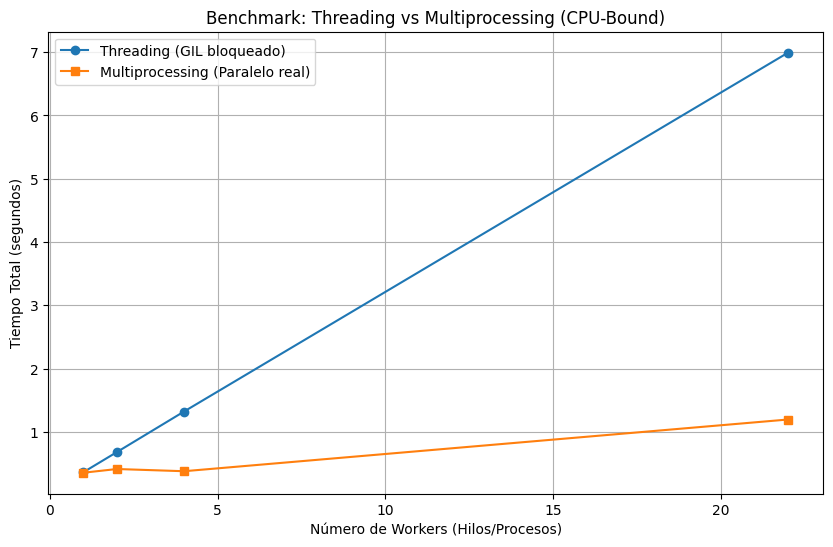


Speedup máximo con Procesos: 5.80x
TODO: implementa benchmark threading vs multiprocessing


In [18]:
# IMPORTANTE: ProcessPoolExecutor requiere funciones picklables
# La función debe estar definida a nivel de módulo (no como lambda ni nested)

def tarea_cpu(n: int) -> int:
    """CPU-bound pura: wait(τᵢ) = ∅"""
    return sum(range(n))

N_TRABAJO = 20_000_000   # ajusta según tu máquina
N_WORKERS_LIST = [1, 2, 4, os.cpu_count()]

# --- Secuencial (baseline) ---
t0 = time.perf_counter()
for w in N_WORKERS_LIST:
    for _ in range(w):
        tarea_cpu(N_TRABAJO)
# Solo mide con N_WORKERS_LIST[-1] para baseline justo
n = N_WORKERS_LIST[-1]
t0 = time.perf_counter()
for _ in range(n): tarea_cpu(N_TRABAJO)
t_seq = time.perf_counter() - t0
print(f"Secuencial ({n} tareas): {t_seq:.2f}s (baseline)")
print()

# TODO: implementa el benchmark para threading y multiprocessing
# Para cada n_workers en [1, 2, 4, os.cpu_count()]:
#   - Mide tiempo con threading.Thread
#   - Mide tiempo con ProcessPoolExecutor
#   - Calcula speedup vs secuencial
# Grafica los resultados con matplotlib

import matplotlib.pyplot as plt

# Listas para almacenar resultados
resultados_threading = []
resultados_mp = []

print(f"{'Workers':<10} | {'Threading':<12} | {'MP (Process)':<12}")
print("-" * 40)

for n_workers in N_WORKERS_LIST:
    # --- 1. Threading Benchmark ---
    t0 = time.perf_counter()
    hilos = []
    for _ in range(n_workers):
        h = threading.Thread(target=tarea_cpu, args=(N_TRABAJO,))
        hilos.append(h)
        h.start()
    for h in hilos:
        h.join()
    t_threads = time.perf_counter() - t0
    resultados_threading.append(t_threads)

    # --- 2. Multiprocessing Benchmark (ProcessPoolExecutor) ---
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        # map reparte las tareas entre los procesos del pool
        list(pool.map(tarea_cpu, [N_TRABAJO] * n_workers))
    t_mp = time.perf_counter() - t0
    resultados_mp.append(t_mp)

    print(f"{n_workers:<10} | {t_threads:>10.2f}s | {t_mp:>10.2f}s")

# --- Graficación de Resultados ---
plt.figure(figsize=(10, 6))
plt.plot(N_WORKERS_LIST, resultados_threading, 'o-', label='Threading (GIL bloqueado)')
plt.plot(N_WORKERS_LIST, resultados_mp, 's-', label='Multiprocessing (Paralelo real)')
plt.xlabel('Número de Workers (Hilos/Procesos)')
plt.ylabel('Tiempo Total (segundos)')
plt.title('Benchmark: Threading vs Multiprocessing (CPU-Bound)')
plt.legend()
plt.grid(True)
plt.show()

# Cálculo de Speedup final para el máximo de núcleos
speedup_mp = t_seq / resultados_mp[-1]
print(f"\nSpeedup máximo con Procesos: {speedup_mp:.2f}x")

print("TODO: implementa benchmark threading vs multiprocessing")

## Sección 7: joblib vs ProcessPoolExecutor — misma tarea

In [ ]:
!pip install joblib 
try:
    from joblib import Parallel, delayed
    JOBLIB_OK = True
except ImportError:
    print("joblib no instalado — pip install joblib")
    JOBLIB_OK = False

if JOBLIB_OK:
    datos = list(range(1_000_000, 1_001_000))   # 1000 tareas
    
    # ProcessPoolExecutor
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=4) as pool:
        resultados_ppe = list(pool.map(tarea_cpu, datos))
    t_ppe = time.perf_counter() - t0
    print(f"ProcessPoolExecutor (4 workers): {t_ppe:.2f}s")
    
    # joblib
    t0 = time.perf_counter()
    resultados_jl = Parallel(n_jobs=4)(delayed(tarea_cpu)(n) for n in datos)
    t_jl = time.perf_counter() - t0
    print(f"joblib.Parallel (n_jobs=4):       {t_jl:.2f}s")
    
    assert resultados_ppe == resultados_jl, "resultados diferentes!"
    print(f"\nResultados idénticos: ✓")
    print(f"\n¿Cuándo preferirías joblib sobre ProcessPoolExecutor?")
    print("Hint: considera la interfaz, integración con numpy, y el backend 'loky'")

ProcessPoolExecutor (4 workers): 3.94s
joblib.Parallel (n_jobs=4):       4.73s

Resultados idénticos: ✓

¿Cuándo preferirías joblib sobre ProcessPoolExecutor?
Hint: considera la interfaz, integración con numpy, y el backend 'loky'


## Sección 8: Anti-patrón lambda (PicklingError)

In [ ]:
# TAREA 8: Reproducir el PicklingError con lambda en ProcessPoolExecutor

# Anti-patrón: lambda no puede ser serializada entre procesos
try:
    with ProcessPoolExecutor(max_workers=2) as pool:
        resultados = list(pool.map(lambda x: x**2, [1, 2, 3, 4]))
    print("¿Sin error? (puede pasar en algunos sistemas)")
    print(resultados)
except Exception as e:
    print(f"Error esperado: {type(e).__name__}: {e}")

print()

# TODO: aplica el fix con una función a nivel de módulo o functools.partial
# Verifica que produce el mismo resultado sin error

# TODO: implementa al_cuadrado como función y usa partial para demostrar ambos fixes
from functools import partial

# FIX 1: Función definida a nivel de módulo
# Esto funciona porque el proceso hijo puede importar el módulo y encontrar 'al_cuadrado' por nombre.
def al_cuadrado(x):
    return x**2

# FIX 2: Usar una función con argumentos pre-configurados (opcional para este caso, pero útil)
# partial es serializable siempre que la función base (al_cuadrado) lo sea.
al_cuadrado_partial = partial(al_cuadrado)

print("=== Aplicando Fixes para evitar PicklingError ===")

try:
    with ProcessPoolExecutor(max_workers=2) as pool:
        # Usando la función a nivel de módulo
        resultados_fix1 = list(pool.map(al_cuadrado, [1, 2, 3, 4]))
        print(f"Fix 1 (Función de módulo): {resultados_fix1}")
        
        # Usando partial
        resultados_fix2 = list(pool.map(al_cuadrado_partial, [5, 6, 7, 8]))
        print(f"Fix 2 (functools.partial): {resultados_fix2}")
        
except Exception as e:
    print(f"Error inesperado: {type(e).__name__}: {e}")

print("\nConclusión: Las funciones deben ser 'picklables' (serializables).")
print("Las lambdas fallan porque no tienen una ruta de importación válida para el proceso hijo.")


Error esperado: PicklingError: Can't pickle <function <lambda> at 0x7980b51c7f60>: attribute lookup <lambda> on __main__ failed

=== Aplicando Fixes para evitar PicklingError ===
Fix 1 (Función de módulo): [1, 4, 9, 16]
Fix 2 (functools.partial): [25, 36, 49, 64]

Conclusión: Las funciones deben ser 'picklables' (serializables).
Las lambdas fallan porque no tienen una ruta de importación válida para el proceso hijo.


## Sección 9: Pool por petición vs pool compartido — medir diferencia

In [10]:
# TAREA 9: Comparar overhead de crear pool por petición vs pool compartido

N_PETICIONES = 20

# Anti-patrón: nuevo pool por petición
t0 = time.perf_counter()
for _ in range(N_PETICIONES):
    with ProcessPoolExecutor(max_workers=2) as pool:
        list(pool.map(tarea_cpu, [100_000, 100_000]))
t_pool_por_peticion = time.perf_counter() - t0
print(f"Pool por petición ({N_PETICIONES} veces): {t_pool_por_peticion:.2f}s")

# Correcto: pool compartido
t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=2) as pool_compartido:
    for _ in range(N_PETICIONES):
        list(pool_compartido.map(tarea_cpu, [100_000, 100_000]))
t_pool_compartido = time.perf_counter() - t0
print(f"Pool compartido ({N_PETICIONES} peticiones): {t_pool_compartido:.2f}s")

print(f"\nOverhead del anti-patrón: {t_pool_por_peticion/t_pool_compartido:.1f}× más lento")
print("El overhead es el costo de crear/destruir procesos N veces en lugar de una.")

Pool por petición (20 veces): 0.37s
Pool compartido (20 peticiones): 0.07s

Overhead del anti-patrón: 5.6× más lento
El overhead es el costo de crear/destruir procesos N veces en lugar de una.


## Sección 10 (opcional): run_in_executor — asyncio + ProcessPoolExecutor

Integra asyncio con ProcessPoolExecutor para manejar carga mixta (I/O + CPU).
Este es el patrón del chatbot v3 (M5b).

In [24]:
# TAREA 10: Implementar M5b — asyncio + ProcessPoolExecutor
#
# Escenario: 10 peticiones llegan simultáneamente.
# Cada petición: consulta BD (I/O, 0.1s) + inferencia LLM local (CPU, 0.5s)
#
# Compara:
#   a) Todo en asyncio con time.sleep (bloquea el event loop durante inferencia)
#   b) asyncio para I/O + run_in_executor(ProcessPoolExecutor) para CPU
#
# ¿Cuánto mejora la versión b sobre la a?
# ¿Cómo se relaciona con la Ley de Amdahl?

N_USUARIOS = 10
T_IO = 0.1    # wait(τᵢ): consulta BD
T_CPU = 0.5   # exec bloqueante: inferencia LLM

def inferencia_local(historial):
    """CPU-bound: simula inferencia del LLM local"""
    time.sleep(T_CPU)   # usa time.sleep para simular blocking CPU work
    return f"respuesta para {historial}"

# TODO: implementa versión a (asyncio puro con time.sleep bloqueante)
# TODO: implementa versión b (asyncio + run_in_executor con ProcessPoolExecutor)
# TODO: mide tiempos y calcula la fracción secuencial S implícita

from concurrent.futures import ProcessPoolExecutor

# --- Versión A: asyncio puro (BLOQUEANTE) ---
async def servidor_v_a(n):
    """M1/M4 fallido: el trabajo CPU bloquea el loop"""
    t0 = time.perf_counter()
    for i in range(n):
        # I/O no bloqueante
        await asyncio.sleep(T_IO)
        # CPU bloqueante: ESTO CONGELA EL EVENT LOOP
        inferencia_local(f"Historial {i}")
    return time.perf_counter() - t0

# --- Versión B: asyncio + run_in_executor (PARALELO) ---
async def servidor_v_b(n):
    """M5b: I/O en loop + CPU en ProcessPool"""
    loop = asyncio.get_running_loop()
    t0 = time.perf_counter()
    
    # Creamos el pool de procesos
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as pool:
        tareas = []
        for i in range(n):
            # 1. Fase I/O: ocurre en el loop principal
            await asyncio.sleep(T_IO)
            
            # 2. Fase CPU: se delega a un proceso hijo
            # run_in_executor no bloquea, devuelve un Future inmediatamente
            tarea = loop.run_in_executor(pool, inferencia_local, f"Historial {i}")
            tareas.append(tarea)
        
        # Esperamos a que todas las inferencias terminen
        await asyncio.gather(*tareas)
        
    return time.perf_counter() - t0

# --- Ejecución y Benchmark ---
print(f"Ejecutando {N_USUARIOS} peticiones mixtas...")

t_a = await servidor_v_a(N_USUARIOS)
print(f"Versión A (Bloqueante): {t_a:.2f}s")

t_b = await servidor_v_b(N_USUARIOS)
print(f"Versión B (Paralelo M5b): {t_b:.2f}s")

# --- Análisis ---
speedup = t_a / t_b
print(f"\nSpeedup: {speedup:.2f}x")

# Cálculo de fracción secuencial S (Ley de Amdahl simplificada)
# S ≈ (Tiempo con N núcleos) / (Tiempo secuencial) si N fuera infinito
# Aquí podemos estimar la fracción que no se pudo paralelizar
print(f"Relación con Amdahl: El tiempo de I/O ({T_IO}s) es puramente secuencial en el loop.")

Ejecutando 10 peticiones mixtas...
Versión A (Bloqueante): 6.01s
Versión B (Paralelo M5b): 1.74s

Speedup: 3.46x
Relación con Amdahl: El tiempo de I/O (0.1s) es puramente secuencial en el loop.
